# 09 — Extensión: forecasting de la PRÓXIMA reunión (X → X+1)

Los experimentos 1–4 clasifican la decisión **de la propia reunión** a partir de su minuta. Esa
formulación tiene una limitación: la minuta **menciona explícitamente** su decisión (*"the Committee
decided to raise/lower/maintain..."*), así que parte de lo que aprenden los modelos —sobre todo
FinBERT— puede ser **leer** la decisión, no inferirla (leakage).

Esta notebook prueba la versión **sin leakage**: predecir la decisión de la reunión **siguiente**
(X → X+1). El texto de la minuta X ya no contiene la respuesta (la decisión de X+1 es futura).
Es forecasting real: *dado el tono/discusión de hoy, ¿qué hará la Fed la próxima vez?*

**Baseline clave: persistencia.** La política monetaria es muy inercial (la Fed encadena subas,
holds o recortes durante varias reuniones). Por eso la vara real no es la clase mayoritaria, sino
**predecir que la próxima decisión = la última decisión**. Cualquier modelo útil tiene que ganarle.

Mismo split cronológico y mismas representaciones que el TP principal, para que la comparación sea
honesta.

**Outputs:** `reports/figures/09_forecasting_f1.png`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 200

BASE_DIR       = Path('..').resolve()
DATA_RAW       = BASE_DIR / 'data' / 'raw'
LEXICONS_DIR   = DATA_RAW / 'lexicons'
MINUTES_DIR    = DATA_RAW / 'minutes'
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR    = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['hike', 'cut', 'hold']

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

# acumulador de resultados (modelo -> f1_val, f1_test)
RES = []
def f1m(y_true, y_pred):
    clases = [c for c in LABEL_ORDER if c in set(y_true)]
    return f1_score(y_true, y_pred, labels=clases, average='macro')
def registrar(nombre, yv, pv, yt, pt):
    fv, ft = f1m(yv, pv), f1m(yt, pt)
    RES.append({'modelo': nombre, 'f1_val': round(fv, 4), 'f1_test': round(ft, 4)})
    print(f'{nombre:32s} F1-macro  val={fv:.4f}  test={ft:.4f}')
    return fv, ft

## 1. Datos — relabel X → X+1

La etiqueta de cada minuta pasa a ser la decisión de la reunión **siguiente**. Se ordena por fecha
y se corre la etiqueta una posición **dentro de cada split** (la última reunión de cada conjunto
queda sin X+1 y se descarta, evitando cruzar el borde entre train/val/test). Guardamos la decisión
actual (`decision_now`) para el baseline de persistencia.

In [2]:
# Forecasting usa el dataset SIN enmascarar: la decisión de la minuta X es un insumo legítimo
# (la respuesta es la decisión de X+1, que no está en el texto de X -> no es leakage). Enmascararla
# mutilaría a los modelos y rompería el sentido de la persistencia.
df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset_unmasked.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
df['decision_now'] = df['label']                                  # decisión de ESTA reunión (persistencia)
df['label'] = df.groupby('split', sort=False)['label'].shift(-1)  # target = decisión de la PRÓXIMA reunión
df = df.dropna(subset=['label']).reset_index(drop=True)

train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']
yv, yt = val['label'], test['label']
print('train:', len(train), '| val:', len(val), '| test:', len(test))
print(pd.crosstab(df['label'], df['split']))

train: 144 | val: 31 | test: 31
split  test  train  val
label                  
cut       6     18    4
hike     11     24    4
hold     14    102   23


## 2. Baselines: mayoritaria y persistencia

- **Mayoritaria**: predice siempre la clase más común de train.
- **Persistencia**: predice que la próxima decisión = la decisión actual (`decision_now`). Es la
  vara real en forecasting.

In [3]:
dummy = DummyClassifier(strategy='prior').fit(train['text'], train['label'])
registrar('Baseline (mayoritaria)', yv, dummy.predict(val['text']), yt, dummy.predict(test['text']))
registrar('Baseline (persistencia)', yv, val['decision_now'], yt, test['decision_now'])

Baseline (mayoritaria)           F1-macro  val=0.2840  test=0.2074
Baseline (persistencia)          F1-macro  val=0.4130  test=0.7680


(0.41304347826086957, 0.7680250783699059)

## 3. Exp 1' — TF-IDF + LogReg (X→X+1)

In [4]:
vec = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
Xtr = vec.fit_transform(train['text']); Xv = vec.transform(val['text']); Xt = vec.transform(test['text'])
best = None
for C in [0.01, 0.1, 1, 10]:
    clf = LogisticRegression(C=C, max_iter=1000, class_weight='balanced').fit(Xtr, train['label'])
    fv = f1m(yv, clf.predict(Xv))
    if best is None or fv > best[0]: best = (fv, C, clf)
clf = best[2]
registrar(f'Exp 1 TF-IDF (C={best[1]})', yv, clf.predict(Xv), yt, clf.predict(Xt))

Exp 1 TF-IDF (C=1)               F1-macro  val=0.4226  test=0.2074


(0.42264150943396234, 0.2074074074074074)

## 4. Exp 2' — Lexicón Loughran-McDonald + LogReg (X→X+1)

In [5]:
LM_PATH = LEXICONS_DIR / 'Loughran-McDonald_MasterDictionary_1993-2025.csv'
if not LM_PATH.exists():
    LM_PATH = LEXICONS_DIR / 'LM_MasterDictionary.csv'
lm_df = pd.read_csv(LM_PATH)
LM_CATEGORIES = ['Positive', 'Negative', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal']
lm_sets = {cat: set(lm_df.loc[lm_df[cat] > 0, 'Word'].dropna().str.lower()) for cat in LM_CATEGORIES}
lm_cols = [f'lm_{c.lower()}' for c in LM_CATEGORIES]

def lm_score(text, ws):
    toks = str(text).split()
    return sum(1 for t in toks if t in ws) / len(toks) if toks else 0.0
for cat, col in zip(LM_CATEGORIES, lm_cols):
    df[col] = df['text'].apply(lambda t, s=lm_sets[cat]: lm_score(t, s))
train = df[df.split == 'train']; val = df[df.split == 'val']; test = df[df.split == 'test']
yv, yt = val['label'], test['label']

best = None
for C in [0.01, 0.1, 1, 10]:
    pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(C=C, max_iter=1000, class_weight='balanced'))])
    pipe.fit(train[lm_cols].values, train['label'])
    fv = f1m(yv, pipe.predict(val[lm_cols].values))
    if best is None or fv > best[0]: best = (fv, C, pipe)
pipe = best[2]
registrar(f'Exp 2 LM lexicón (C={best[1]})', yv, pipe.predict(val[lm_cols].values), yt, pipe.predict(test[lm_cols].values))

Exp 2 LM lexicón (C=0.01)        F1-macro  val=0.3569  test=0.1677


(0.3568868407578085, 0.16765873015873015)

## 5. Exp 3' — Word2Vec mean pooling + LogReg (X→X+1)

In [6]:
import gensim.downloader as api
wv = api.load('word2vec-google-news-300'); DIM = wv.vector_size

def doc_vector(text):
    toks = [t for t in str(text).split() if t in wv]
    return np.mean([wv[t] for t in toks], axis=0) if toks else np.zeros(DIM, dtype=np.float32)
Xtr = np.vstack([doc_vector(t) for t in train['text']])
Xv  = np.vstack([doc_vector(t) for t in val['text']])
Xt  = np.vstack([doc_vector(t) for t in test['text']])

best = None
for C in [0.01, 0.1, 1, 10]:
    pipe = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(C=C, max_iter=1000, class_weight='balanced'))])
    pipe.fit(Xtr, train['label'])
    fv = f1m(yv, pipe.predict(Xv))
    if best is None or fv > best[0]: best = (fv, C, pipe)
pipe = best[2]
registrar(f'Exp 3 Word2Vec (C={best[1]})', yv, pipe.predict(Xv), yt, pipe.predict(Xt))

Exp 3 Word2Vec (C=0.1)           F1-macro  val=0.4333  test=0.2984


(0.43333333333333335, 0.2984126984126984)

## 6. Exp 4' — FinBERT (X→X+1)  ·  PESADO, correr en GPU

FinBERT con texto crudo. **4a** feature extraction (congelado, chunking) + LogReg; **4b**
fine-tuning completo. Pesado en CPU/MPS → poné `RUN_FINBERT = True` en la PC con GPU para
completar estas dos filas de la comparación.

In [6]:
RUN_FINBERT = True  # poné True en la PC con GPU

if RUN_FINBERT:
    import re, torch
    from torch import nn
    from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
                              TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback)
    MODEL_NAME = 'ProsusAI/finbert'
    device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
    print('Device:', device)

    # Forecasting: NO enmascarar. El crudo se usa tal cual (la decisión de X es insumo legítimo).
    def raw_text(date):
        f = MINUTES_DIR / f"{pd.to_datetime(date).strftime('%Y-%m-%d')}_minutes.txt"
        return re.sub(r'\s+', ' ', f.read_text(encoding='utf-8', errors='replace')).strip()
    df['raw'] = df['date'].apply(raw_text)
    tr = df[df.split=='train']; va = df[df.split=='val']; te = df[df.split=='test']
    yv2, yt2 = va['label'], te['label']

    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    CLS, SEP = tok.cls_token_id, tok.sep_token_id
    def ids_head_tail(t, nh=255, nt=255):
        ids = tok(t, add_special_tokens=False, truncation=False)['input_ids']
        if len(ids) > nh+nt: ids = ids[:nh] + ids[-nt:]
        return [CLS] + ids + [SEP]
    def ids_chunks(t, size=512):
        ids = tok(t, add_special_tokens=False, truncation=False)['input_ids']; step = size-2
        return [[CLS] + ids[i:i+step] + [SEP] for i in range(0, max(len(ids),1), step)]

    # --- 4a feature extraction (chunking, como en el TP) ---
    enc = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
    @torch.inference_mode()
    def cls_emb(input_ids):
        return enc(torch.tensor([input_ids], device=device)).last_hidden_state[0,0].cpu().numpy()
    def embed_chunk(t):
        return np.mean([cls_emb(c) for c in ids_chunks(t)], axis=0)
    Ftr = np.vstack([embed_chunk(t) for t in tr['raw']])
    Fv  = np.vstack([embed_chunk(t) for t in va['raw']])
    Ft  = np.vstack([embed_chunk(t) for t in te['raw']])
    best = None
    for C in [0.01, 0.1, 1, 10]:
        clf = LogisticRegression(C=C, max_iter=2000, class_weight='balanced').fit(Ftr, tr['label'])
        fv = f1m(yv2, clf.predict(Fv))
        if best is None or fv > best[0]: best = (fv, C, clf)
    clf = best[2]
    registrar(f'Exp 4a FinBERT frozen (C={best[1]})', yv2, clf.predict(Fv), yt2, clf.predict(Ft))

    # --- 4b fine-tuning ---
    label2id = {l:i for i,l in enumerate(LABEL_ORDER)}; id2label = {i:l for l,i in label2id.items()}
    class DS(torch.utils.data.Dataset):
        def __init__(s, texts, labels): s.t=list(texts); s.l=[label2id[x] for x in labels]
        def __len__(s): return len(s.t)
        def __getitem__(s, i):
            ids = ids_head_tail(s.t[i]); return {'input_ids': ids, 'attention_mask':[1]*len(ids), 'labels': s.l[i]}
    dtr, dva, dte = DS(tr['raw'], tr['label']), DS(va['raw'], va['label']), DS(te['raw'], te['label'])
    collator = DataCollatorWithPadding(tok)
    counts = tr['label'].value_counts()
    w = torch.tensor([len(tr)/(3*counts[l]) for l in LABEL_ORDER], dtype=torch.float)
    class WT(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kw):
            labels = inputs.pop('labels'); out = model(**inputs)
            loss = nn.CrossEntropyLoss(weight=w.to(model.device))(out.logits, labels)
            return (loss, out) if return_outputs else loss
    def cmetrics(p): return {'f1_macro': f1_score(p.label_ids, np.argmax(p.predictions, axis=-1), average='macro')}
    def train_one(lr, bs, epochs=5):
        m = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id).to(device)
        args = TrainingArguments(output_dir=str(BASE_DIR/'tmp_finbert_fc'/f'lr{lr}_bs{bs}'), learning_rate=lr,
            per_device_train_batch_size=bs, per_device_eval_batch_size=16, num_train_epochs=epochs,
            eval_strategy='epoch', save_strategy='epoch', logging_strategy='epoch', load_best_model_at_end=True,
            metric_for_best_model='f1_macro', greater_is_better=True, weight_decay=0.01, seed=33,
            report_to='none', disable_tqdm=True, save_total_limit=1)
        tr_ = WT(model=m, args=args, train_dataset=dtr, eval_dataset=dva, data_collator=collator,
                 compute_metrics=cmetrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
        tr_.train(); return tr_, tr_.evaluate(dva)['eval_f1_macro']
    bft = None
    for lr in [1e-5, 2e-5, 5e-5]:
        for bs in [4, 8, 16]:
            t_, fv = train_one(lr, bs)
            if bft is None or fv > bft[0]: bft = (fv, lr, bs, t_)
    def preds(t_, ds): return [id2label[i] for i in np.argmax(t_.predict(ds).predictions, axis=-1)]
    registrar(f'Exp 4b FinBERT fine-tuning', yv2, preds(bft[3], dva), yt2, preds(bft[3], dte))
else:
    print('FinBERT SKIP (RUN_FINBERT=False). Correr en GPU para sumar 4a y 4b a la comparación.')

D:\User\Documentos\ITBA_YO\3er\2do_cuatrimestre\NLP\TP_NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35437.80it/s]


[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.64it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]

{'train_runtime': '49.06', 'train_samples_per_second': '14.68', 'train_steps_per_second': '0.917', 'train_loss': '0.6856', 'epoch': '5'}


{'eval_loss': '1.586', 'eval_f1_macro': '0.4266', 'eval_runtime': '1.138', 'eval_samples_per_second': '27.25', 'eval_steps_per_second': '1.758', 'epoch': '5'}


Exp 4b FinBERT fine-tuning       F1-macro  val=0.5022  test=0.4750


## 7. Comparación — ¿algún modelo le gana a la persistencia?

,f1_val,f1_test
modelo,,
Baseline (mayoritaria),0.2840,0.2074
Baseline (persistencia),0.4130,0.7680
Exp 1 TF-IDF (C=1),0.4226,0.2074
Exp 2 LM lexicón (C=0.01),0.3569,0.1677
Exp 3 Word2Vec (C=0.1),0.4333,0.2984
Exp 4a FinBERT frozen (C=0.01),0.3495,0.4339
Exp 4b FinBERT fine-tuning,0.5022,0.4750


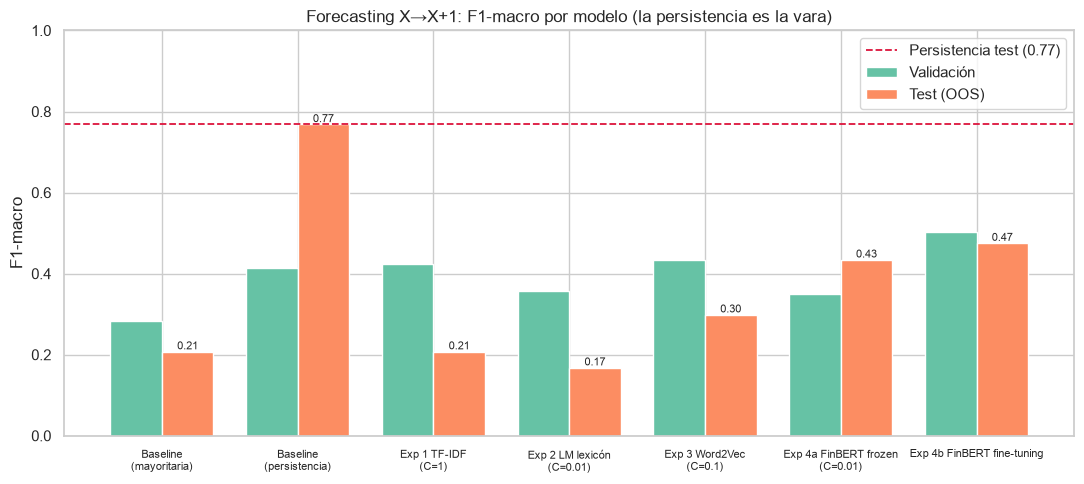

In [7]:
res = pd.DataFrame(RES)
display(res.set_index('modelo'))
persist_test = res.loc[res.modelo == 'Baseline (persistencia)', 'f1_test'].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(res)); width = 0.38
ax.bar(x - width/2, res['f1_val'],  width, label='Validación', color='#66c2a5')
ax.bar(x + width/2, res['f1_test'], width, label='Test (OOS)', color='#fc8d62')
ax.axhline(persist_test, ls='--', c='crimson', lw=1.3, label=f'Persistencia test ({persist_test:.2f})')
ax.set_ylabel('F1-macro'); ax.set_ylim(0, 1)
ax.set_title('Forecasting X→X+1: F1-macro por modelo (la persistencia es la vara)')
ax.set_xticks(x); ax.set_xticklabels([m.replace(' (', '\n(') for m in res['modelo']], fontsize=8)
ax.legend()
for i, r in res.iterrows():
    ax.annotate(f"{r['f1_test']:.2f}", (i + width/2, r['f1_test']), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); save_fig('09_forecasting_f1.png'); plt.show()

## 8. Conclusión

**Ningún modelo le gana a la persistencia.** En test la persistencia alcanza F1-macro **0.768**;
el mejor modelo textual es FinBERT fine-tuneado con apenas **0.475** (FinBERT frozen 0.434,
Word2Vec 0.298, TF-IDF y LM ≈ 0.17–0.21). Ni siquiera el transformer financiero adaptado a la
tarea se acerca a la vara inercial: la brecha es de casi 30 puntos de F1-macro.

| Modelo (X→X+1) | val | test |
|---|---|---|
| Baseline mayoritaria | 0.284 | 0.207 |
| **Persistencia** | **0.413** | **0.768** |
| Exp 1 TF-IDF | 0.423 | 0.207 |
| Exp 2 LM lexicón | 0.357 | 0.168 |
| Exp 3 Word2Vec | 0.433 | 0.298 |
| Exp 4a FinBERT frozen | 0.350 | 0.434 |
| Exp 4b FinBERT fine-tuning | 0.502 | 0.475 |

La línea roja punteada es la persistencia en test. La lectura del experimento: **ninguna barra de
test supera esa línea, así que el texto de la minuta no aporta sobre la inercia** — predecir el
próximo movimiento se reduce a "la Fed sigue haciendo lo mismo". La política monetaria es
fuertemente autocorrelacionada (rachas de subas / holds / recortes), y la persistencia captura eso
sin leer una sola palabra. Es notable que FinBERT (4a/4b) sí supere a los modelos clásicos en este
escenario (test 0.43–0.48 vs 0.17–0.30): algo de señal anticipatoria capta del tono de la discusión,
pero no la suficiente para vencer a la inercia.

Esto justifica la formulación del TP principal (clasificar la decisión de la propia reunión): es
donde el contenido textual sí discrimina. La extensión muestra el límite honesto: **anticipar la
siguiente decisión desde el texto es mucho más difícil, y la inercia es una vara muy alta.**